In [1]:
# =========================
# Install libraries
# =========================
!pip install xgboost lightgbm -q

In [2]:
# =========================
# Imports
# =========================

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.svm import SVC, OneClassSVM
from sklearn.neighbors import KNeighborsClassifier, LocalOutlierFactor
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [3]:
# =========================
# 1. Load IoT-23 Zeek file
# =========================

file_path = "/content/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv"

# The previous code block for extracting columns (with open(...) and #fields) is removed
# because the file format seems to be a standard CSV with a header, not requiring
# special parsing for column names from a '#fields' line.

df = pd.read_csv(
    file_path,
    sep=",", # Changed separator to comma for a .csv file
    # Removed 'comment="#"' and 'names=columns' as pandas will infer headers by default
    low_memory=False
)

df.columns = df.columns.str.strip()

print("Original dataset shape:", df.shape)
print(df.head())

Original dataset shape: (225745, 79)
   Destination Port  Flow Duration  Total Fwd Packets  Total Backward Packets  \
0             54865              3                  2                       0   
1             55054            109                  1                       1   
2             55055             52                  1                       1   
3             46236             34                  1                       1   
4             54863              3                  2                       0   

   Total Length of Fwd Packets  Total Length of Bwd Packets  \
0                           12                            0   
1                            6                            6   
2                            6                            6   
3                            6                            6   
4                           12                            0   

   Fwd Packet Length Max  Fwd Packet Length Min  Fwd Packet Length Mean  \
0                     

In [4]:
# =========================
# 2. Data cleaning - Top Feature Experiment
# =========================

df = df.replace(["-", "?", "nan", "NaN", "inf", "-inf", "Infinity"], np.nan)

# =========================
# Choose feature set
# =========================

# Experiment A: Top 10 features
features = [
    "Init_Win_bytes_forward",
    "Total Length of Fwd Packets",
    "Flow IAT Min",
    "Flow Duration",
    "Active Mean",
    "Init_Win_bytes_backward",
    "Bwd Packets/s",
    "Flow Bytes/s",
    "Fwd Packet Length Max"
]



label_column_name = "Label"

# =========================
# Check columns exist
# =========================

missing_features = [col for col in features if col not in df.columns]

if missing_features:
    raise KeyError(f"These selected features are missing from dataset: {missing_features}")

if label_column_name not in df.columns:
    raise KeyError("Label column not found. Please check column name.")

# =========================
# Create df_model
# =========================

df_model = df[features + [label_column_name]].copy()

# =========================
# Convert label: Benign = 0, Attack = 1
# =========================

df_model[label_column_name] = df_model[label_column_name].apply(
    lambda x: 0 if str(x).strip().lower() == "benign" else 1
)

# Rename label column to standard name
df_model.rename(columns={label_column_name: "label"}, inplace=True)

# =========================
# Convert features to numeric
# =========================

for col in features:
    df_model[col] = pd.to_numeric(df_model[col], errors="coerce")

# =========================
# Remove infinity and fill missing values
# =========================

df_model.replace([np.inf, -np.inf], np.nan, inplace=True)

df_model[features] = df_model[features].fillna(df_model[features].median())
df_model[features] = df_model[features].fillna(0)

# =========================
# Final checks
# =========================

print("Selected features:")
print(features)

print("\nCleaned dataset shape:", df_model.shape)

print("\nLabel distribution:")
print(df_model["label"].value_counts())

print("\nNaN count:", df_model[features].isna().sum().sum())
print("Infinite count:", np.isinf(df_model[features]).sum().sum())

Selected features:
['Init_Win_bytes_forward', 'Total Length of Fwd Packets', 'Flow IAT Min', 'Flow Duration', 'Active Mean', 'Init_Win_bytes_backward', 'Bwd Packets/s', 'Flow Bytes/s', 'Fwd Packet Length Max']

Cleaned dataset shape: (225745, 10)

Label distribution:
label
1    128027
0     97718
Name: count, dtype: int64

NaN count: 0
Infinite count: 0


In [5]:
# =========================
# 3. Split X and y
# =========================

X = df_model[features]
y = df_model["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
    # Removed stratify=y because the minority class has only one sample
)

In [6]:
# =========================
# 4. Scale features
# =========================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Benign-only training data for unsupervised models
X_train_normal = X_train_scaled[y_train == 0]

print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)
print("X_train_normal:", X_train_normal.shape)

print("NaN in train:", np.isnan(X_train_scaled).sum())
print("NaN in test:", np.isnan(X_test_scaled).sum())

X_train_scaled: (180596, 9)
X_test_scaled: (45149, 9)
X_train_normal: (78313, 9)
NaN in train: 0
NaN in test: 0


In [7]:
# =========================
# Supervised ML models
# =========================

supervised_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),

    "Decision Tree": DecisionTreeClassifier(random_state=42),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),

    #"SVM": SVC(
     #   kernel="linear",
     #   probability=False,
      #  random_state=42
    #),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "XGBoost": XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=100,
        learning_rate=0.1,
        random_state=42,
        n_jobs=-1
    )
}

In [8]:
# =========================
# Evaluate supervised models
# =========================

supervised_results = []
trained_supervised_models = {}

for name, model in supervised_models.items():
    print(f"\nTraining {name}...")

    start_train = time.time()
    model.fit(X_train_scaled, y_train)
    train_time = time.time() - start_train

    start_pred = time.time()
    y_pred = model.predict(X_test_scaled)
    pred_time = time.time() - start_pred

    latency = pred_time / len(X_test_scaled)

    try:
        y_score = model.predict_proba(X_test_scaled)[:, 1]
        auc = roc_auc_score(y_test, y_score)
    except:
        auc = np.nan

    supervised_results.append({
        "Model": name,
        "Type": "Supervised",
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-score": f1_score(y_test, y_pred, zero_division=0),
        "AUC": auc,
        "Training Time (s)": train_time,
        "Prediction Time (s)": pred_time,
        "Latency per Sample (s)": latency
    })

    trained_supervised_models[name] = model

supervised_results_df = pd.DataFrame(supervised_results)
supervised_results_df


Training Logistic Regression...

Training Decision Tree...

Training Random Forest...

Training KNN...

Training XGBoost...

Training LightGBM...
[LightGBM] [Info] Number of positive: 102283, number of negative: 78313
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.021082 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2294
[LightGBM] [Info] Number of data points in the train set: 180596, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.566364 -> initscore=0.267030
[LightGBM] [Info] Start training from score 0.267030


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,Model,Type,Accuracy,Precision,Recall,F1-score,AUC,Training Time (s),Prediction Time (s),Latency per Sample (s)
0,Logistic Regression,Supervised,0.900086,0.851761,0.998563,0.919338,0.917713,2.842302,0.001562,3.459918e-08
1,Decision Tree,Supervised,0.999734,0.999728,0.999806,0.999767,0.999723,0.945216,0.005146,1.139840e-07
2,Random Forest,Supervised,0.999934,0.999922,0.999961,0.999942,0.999980,44.384680,0.354970,7.862189e-06
3,KNN,Supervised,0.998738,0.998757,0.999029,0.998893,0.999326,1.029322,9.466420,2.096706e-04
4,XGBoost,Supervised,0.999889,0.999922,0.999883,0.999903,0.999996,1.468655,0.104659,2.318077e-06
5,LightGBM,Supervised,0.999956,0.999961,0.999961,0.999961,0.999996,1.738090,0.114260,2.530725e-06


In [9]:
# =========================
# Unsupervised anomaly models
# =========================

unsupervised_models = {
    "Isolation Forest": IsolationForest(
        n_estimators=100,
        contamination=0.1,
        random_state=42
    ),

    #"One-Class SVM": OneClassSVM(
       # kernel="rbf",
      #  nu=0.1,
       # gamma="scale"
   # ),

    "Local Outlier Factor": LocalOutlierFactor(
        n_neighbors=20,
        contamination=0.1,
        novelty=True
    )
}

In [10]:
# =========================
# Evaluate unsupervised models
# =========================

unsupervised_results = []
trained_unsupervised_models = {}

for name, model in unsupervised_models.items():
    print(f"\nTraining {name}...")

    start_train = time.time()
    model.fit(X_train_normal)
    train_time = time.time() - start_train

    start_pred = time.time()
    pred = model.predict(X_test_scaled)
    pred_time = time.time() - start_pred

    # sklearn anomaly output:
    # 1 = normal, -1 = anomaly
    y_pred = np.where(pred == -1, 1, 0)

    latency = pred_time / len(X_test_scaled)

    try:
        scores = -model.decision_function(X_test_scaled)
        auc = roc_auc_score(y_test, scores)
    except:
        auc = np.nan

    unsupervised_results.append({
        "Model": name,
        "Type": "Unsupervised",
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-score": f1_score(y_test, y_pred, zero_division=0),
        "AUC": auc,
        "Training Time (s)": train_time,
        "Prediction Time (s)": pred_time,
        "Latency per Sample (s)": latency
    })

    trained_unsupervised_models[name] = model

unsupervised_results_df = pd.DataFrame(unsupervised_results)
unsupervised_results_df


Training Isolation Forest...

Training Local Outlier Factor...


,Model,Type,Accuracy,Precision,Recall,F1-score,AUC,Training Time (s),Prediction Time (s),Latency per Sample (s)
0,Isolation Forest,Unsupervised,0.413630,0.390060,0.050303,0.089114,0.388423,0.772786,0.214884,0.000005
1,Local Outlier Factor,Unsupervised,0.860462,0.918511,0.828814,0.871360,0.926179,10.344682,9.377344,0.000208


In [11]:
# =========================
# Final model comparison table
# =========================

final_results = pd.concat(
    [supervised_results_df, unsupervised_results_df],
    ignore_index=True
)

final_results = final_results.sort_values(
    by="F1-score",
    ascending=False
)

final_results

,Model,Type,Accuracy,Precision,Recall,F1-score,AUC,Training Time (s),Prediction Time (s),Latency per Sample (s)
5,LightGBM,Supervised,0.999956,0.999961,0.999961,0.999961,0.999996,1.738090,0.114260,2.530725e-06
2,Random Forest,Supervised,0.999934,0.999922,0.999961,0.999942,0.999980,44.384680,0.354970,7.862189e-06
4,XGBoost,Supervised,0.999889,0.999922,0.999883,0.999903,0.999996,1.468655,0.104659,2.318077e-06
1,Decision Tree,Supervised,0.999734,0.999728,0.999806,0.999767,0.999723,0.945216,0.005146,1.139840e-07
3,KNN,Supervised,0.998738,0.998757,0.999029,0.998893,0.999326,1.029322,9.466420,2.096706e-04
0,Logistic Regression,Supervised,0.900086,0.851761,0.998563,0.919338,0.917713,2.842302,0.001562,3.459918e-08
7,Local Outlier Factor,Unsupervised,0.860462,0.918511,0.828814,0.871360,0.926179,10.344682,9.377344,2.076977e-04
6,Isolation Forest,Unsupervised,0.413630,0.390060,0.050303,0.089114,0.388423,0.772786,0.214884,4.759447e-06


In [12]:
# =========================
# Save model comparison results
# =========================

final_results.to_csv("model_comparison_results.csv", index=False)
print("Saved: model_comparison_results.csv")

Saved: model_comparison_results.csv


In [13]:
# =========================
# Confusion matrices and reports
# =========================

for name, model in trained_supervised_models.items():
    print("\n==============================")
    print(name)
    print("==============================")

    y_pred = model.predict(X_test_scaled)

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))


Logistic Regression
Confusion Matrix:
[[14931  4474]
 [   37 25707]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.77      0.87     19405
           1       0.85      1.00      0.92     25744

    accuracy                           0.90     45149
   macro avg       0.92      0.88      0.89     45149
weighted avg       0.91      0.90      0.90     45149


Decision Tree
Confusion Matrix:
[[19398     7]
 [    5 25739]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19405
           1       1.00      1.00      1.00     25744

    accuracy                           1.00     45149
   macro avg       1.00      1.00      1.00     45149
weighted avg       1.00      1.00      1.00     45149


Random Forest
Confusion Matrix:
[[19403     2]
 [    1 25743]]

Classification Report:
              precision    recall  f1-score   support

           0       1.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [14]:
for name, model in trained_unsupervised_models.items():
    print("\n==============================")
    print(name)
    print("==============================")

    pred = model.predict(X_test_scaled)
    y_pred = np.where(pred == -1, 1, 0)

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))


Isolation Forest
Confusion Matrix:
[[17380  2025]
 [24449  1295]]

Classification Report:
              precision    recall  f1-score   support

           0       0.42      0.90      0.57     19405
           1       0.39      0.05      0.09     25744

    accuracy                           0.41     45149
   macro avg       0.40      0.47      0.33     45149
weighted avg       0.40      0.41      0.29     45149


Local Outlier Factor
Confusion Matrix:
[[17512  1893]
 [ 4407 21337]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.90      0.85     19405
           1       0.92      0.83      0.87     25744

    accuracy                           0.86     45149
   macro avg       0.86      0.87      0.86     45149
weighted avg       0.87      0.86      0.86     45149



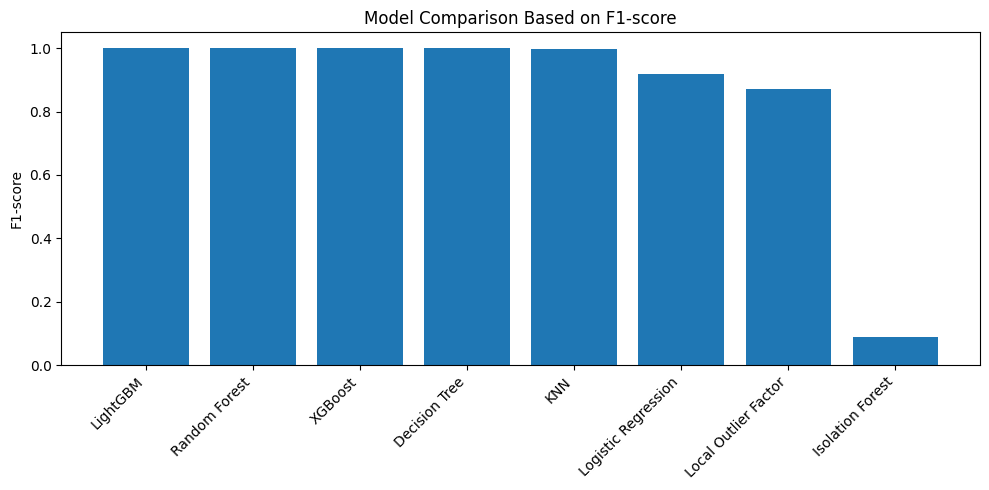

In [15]:
# =========================
# Bar chart: model comparison
# =========================

plt.figure(figsize=(10, 5))
plt.bar(final_results["Model"], final_results["F1-score"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("F1-score")
plt.title("Model Comparison Based on F1-score")
plt.tight_layout()
plt.show()

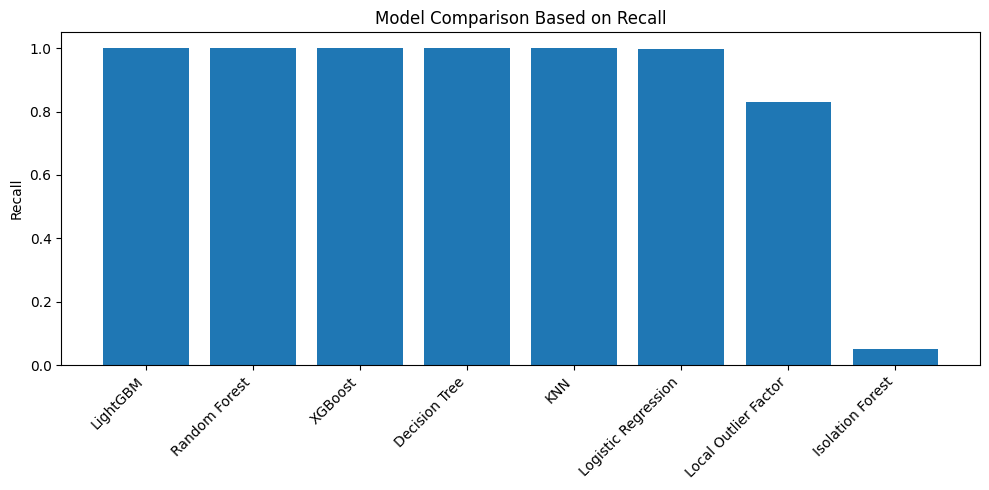

In [16]:
# =========================
# Plot Recall comparison
# =========================

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(final_results["Model"], final_results["Recall"])

plt.xticks(rotation=45, ha="right")

plt.ylabel("Recall")

plt.title("Model Comparison Based on Recall")

plt.ylim(0, 1.05)

plt.tight_layout()

plt.show()

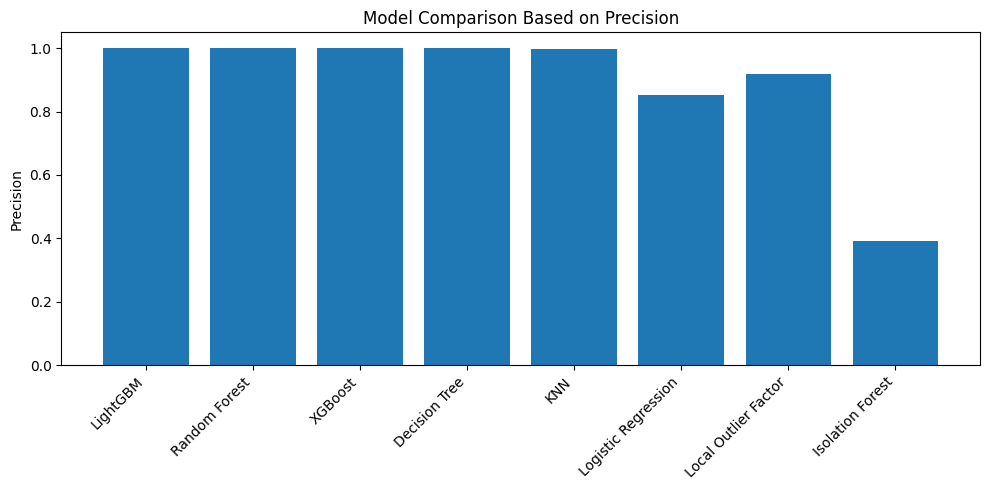

In [17]:
# =========================
# Plot Precision comparison
# =========================

plt.figure(figsize=(10,5))

plt.bar(final_results["Model"], final_results["Precision"])

plt.xticks(rotation=45, ha="right")

plt.ylabel("Precision")

plt.title("Model Comparison Based on Precision")

plt.ylim(0, 1.05)

plt.tight_layout()

plt.show()

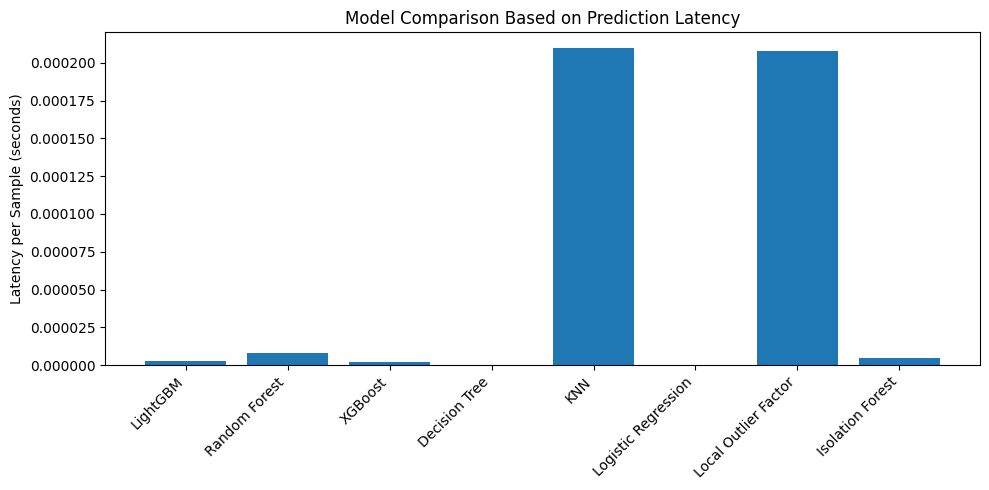

In [18]:
plt.figure(figsize=(10, 5))
plt.bar(final_results["Model"], final_results["Latency per Sample (s)"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Latency per Sample (seconds)")
plt.title("Model Comparison Based on Prediction Latency")
plt.tight_layout()
plt.show()

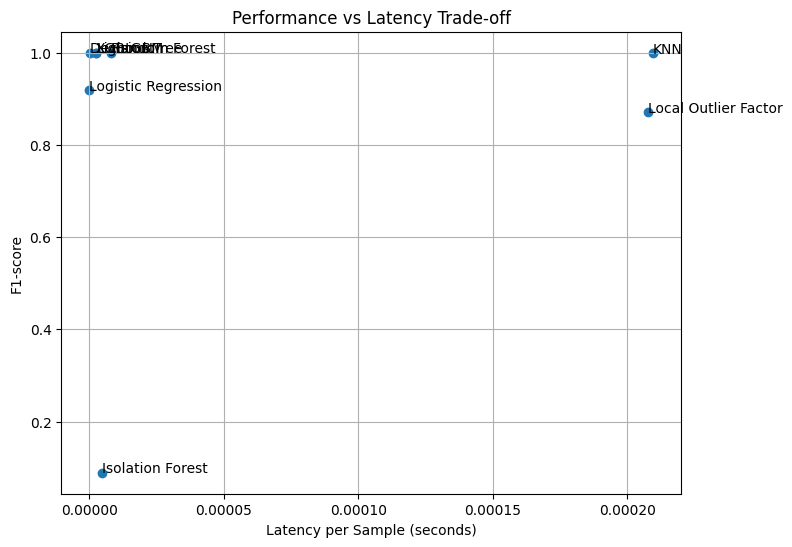

In [19]:
# =========================
# F1-score vs Latency
# =========================

plt.figure(figsize=(8,6))

plt.scatter(
    final_results["Latency per Sample (s)"],
    final_results["F1-score"]
)

for i, row in final_results.iterrows():
    plt.text(
        row["Latency per Sample (s)"],
        row["F1-score"],
        row["Model"]
    )

plt.xlabel("Latency per Sample (seconds)")
plt.ylabel("F1-score")

plt.title("Performance vs Latency Trade-off")

plt.grid(True)

plt.show()

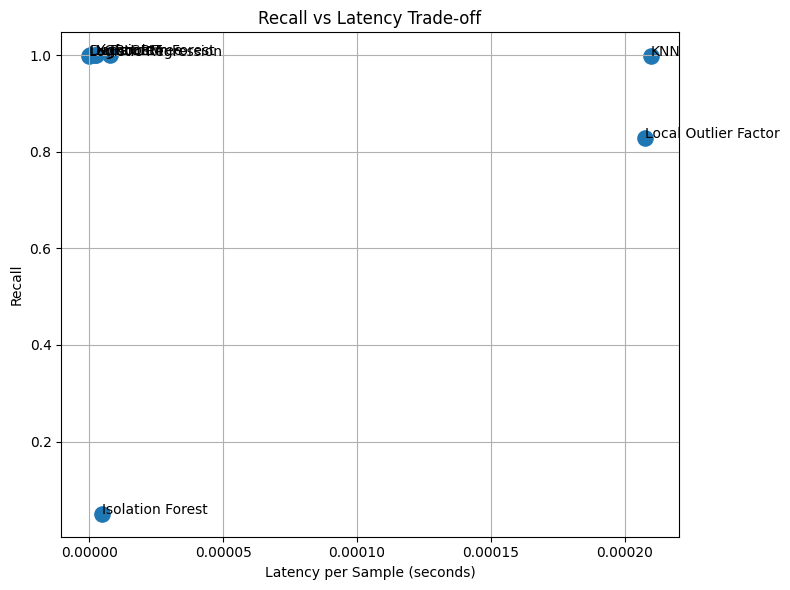

In [20]:
# =========================
# Recall vs Latency Trade-off
# =========================

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

# Scatter plot
plt.scatter(
    final_results["Latency per Sample (s)"],
    final_results["Recall"],
    s=120
)

# Add model labels
for i, row in final_results.iterrows():
    plt.text(
        row["Latency per Sample (s)"],
        row["Recall"],
        row["Model"],
        fontsize=10
    )

plt.xlabel("Latency per Sample (seconds)")
plt.ylabel("Recall")

plt.title("Recall vs Latency Trade-off")

plt.grid(True)

plt.tight_layout()

plt.show()

In [21]:
# =========================
# Feature importance function
# =========================

def get_feature_importance(model, model_name, features):
    importance = model.feature_importances_

    fi_df = pd.DataFrame({
        "Feature": features,
        "Importance": importance
    }).sort_values(by="Importance", ascending=False)

    print(f"\n{model_name} Feature Importance")
    display(fi_df)

    plt.figure(figsize=(8, 5))
    plt.barh(fi_df["Feature"], fi_df["Importance"])
    plt.gca().invert_yaxis()
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.title(f"{model_name} Feature Importance")
    plt.tight_layout()
    plt.show()

    return fi_df


Random Forest Feature Importance


,Feature,Importance
1,Total Length of Fwd Packets,0.317396
0,Init_Win_bytes_forward,0.279721
8,Fwd Packet Length Max,0.248709
5,Init_Win_bytes_backward,0.051776
3,Flow Duration,0.050275
7,Flow Bytes/s,0.019125
6,Bwd Packets/s,0.016739
2,Flow IAT Min,0.013683
4,Active Mean,0.002575


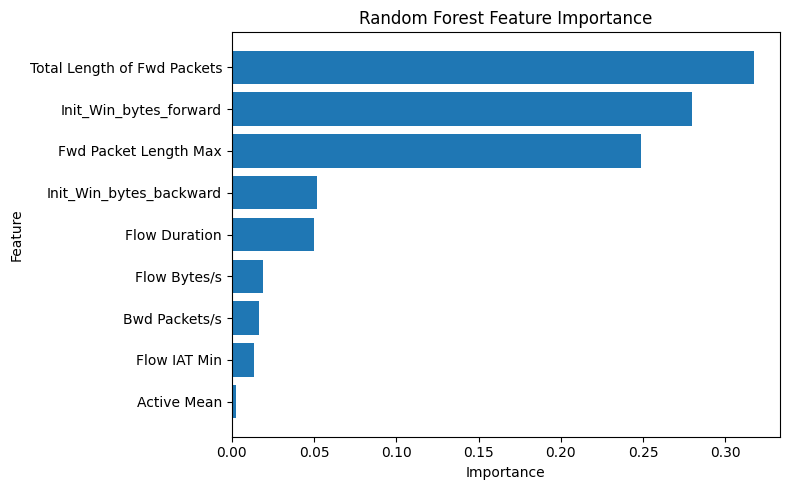


XGBoost Feature Importance


,Feature,Importance
8,Fwd Packet Length Max,0.727602
1,Total Length of Fwd Packets,0.261576
0,Init_Win_bytes_forward,0.007124
5,Init_Win_bytes_backward,0.001056
6,Bwd Packets/s,0.000814
2,Flow IAT Min,0.000650
3,Flow Duration,0.000514
7,Flow Bytes/s,0.000445
4,Active Mean,0.000219


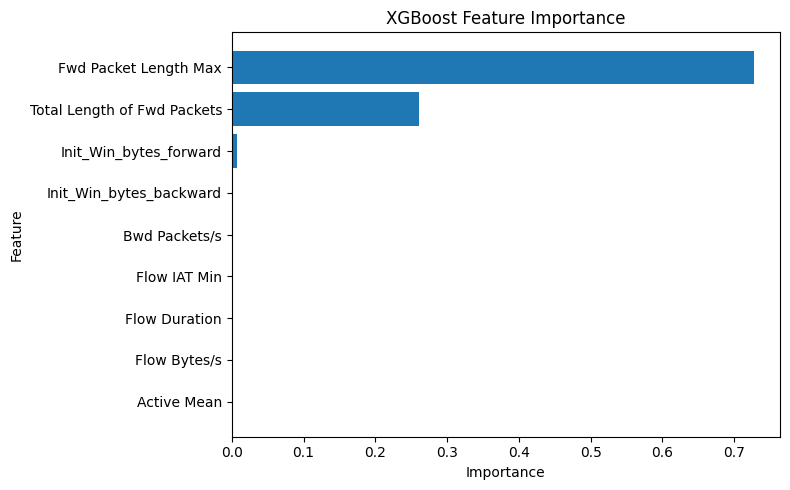


LightGBM Feature Importance


,Feature,Importance
0,Init_Win_bytes_forward,751
3,Flow Duration,434
5,Init_Win_bytes_backward,420
7,Flow Bytes/s,415
2,Flow IAT Min,382
1,Total Length of Fwd Packets,268
6,Bwd Packets/s,148
8,Fwd Packet Length Max,111
4,Active Mean,71


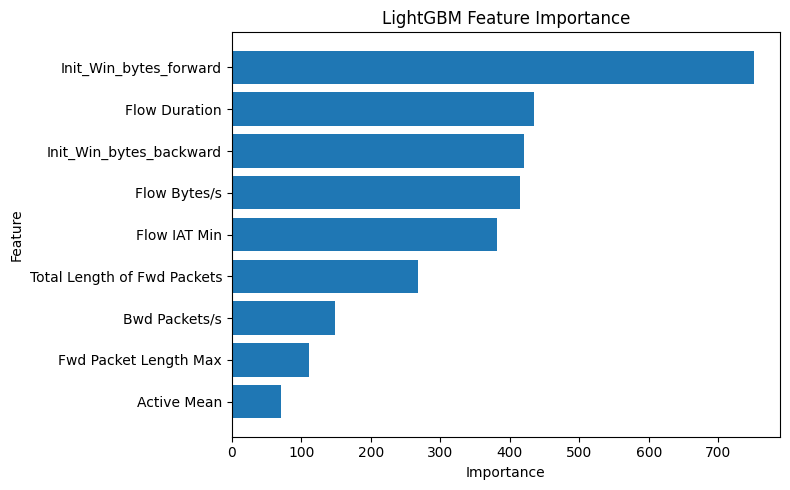

In [22]:
# =========================
# Feature importance from tree-based models
# =========================

rf_importance = get_feature_importance(
    trained_supervised_models["Random Forest"],
    "Random Forest",
    features
)

xgb_importance = get_feature_importance(
    trained_supervised_models["XGBoost"],
    "XGBoost",
    features
)

lgbm_importance = get_feature_importance(
    trained_supervised_models["LightGBM"],
    "LightGBM",
    features
)

In [23]:
# =========================
# Combined average feature importance
# =========================

combined_importance = pd.DataFrame({
    "Feature": features
})

combined_importance = combined_importance.merge(
    rf_importance.rename(columns={"Importance": "Random Forest"}),
    on="Feature"
)

combined_importance = combined_importance.merge(
    xgb_importance.rename(columns={"Importance": "XGBoost"}),
    on="Feature"
)

combined_importance = combined_importance.merge(
    lgbm_importance.rename(columns={"Importance": "LightGBM"}),
    on="Feature"
)

combined_importance["Average Importance"] = combined_importance[
    ["Random Forest", "XGBoost", "LightGBM"]
].mean(axis=1)

combined_importance = combined_importance.sort_values(
    by="Average Importance",
    ascending=False
)

combined_importance

,Feature,Random Forest,XGBoost,LightGBM,Average Importance
0,Init_Win_bytes_forward,0.279721,0.007124,751,250.428948
3,Flow Duration,0.050275,0.000514,434,144.683596
5,Init_Win_bytes_backward,0.051776,0.001056,420,140.017611
7,Flow Bytes/s,0.019125,0.000445,415,138.339857
2,Flow IAT Min,0.013683,0.000650,382,127.338111
1,Total Length of Fwd Packets,0.317396,0.261576,268,89.526324
6,Bwd Packets/s,0.016739,0.000814,148,49.339184
8,Fwd Packet Length Max,0.248709,0.727602,111,37.325437
4,Active Mean,0.002575,0.000219,71,23.667598


In [24]:
# =========================
# Save feature importance
# =========================

combined_importance.to_csv("feature_importance_results.csv", index=False)
print("Saved: feature_importance_results.csv")

Saved: feature_importance_results.csv


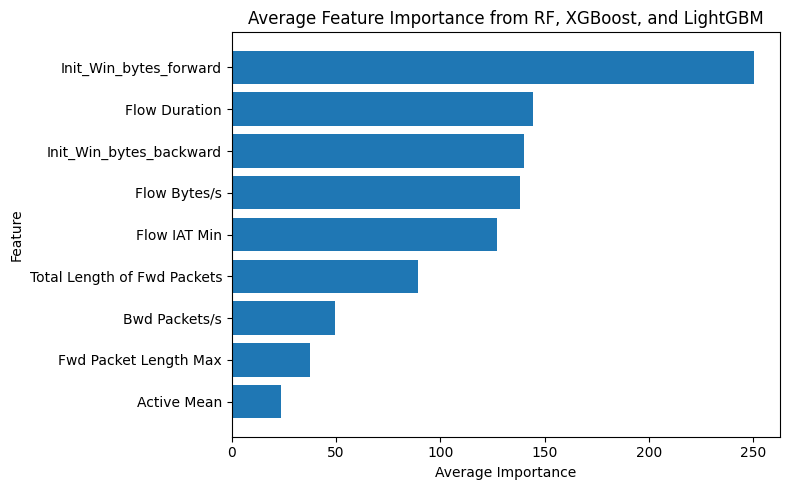

In [25]:
# =========================
# Plot average feature importance
# =========================

plt.figure(figsize=(8, 5))
plt.barh(
    combined_importance["Feature"],
    combined_importance["Average Importance"]
)
plt.gca().invert_yaxis()
plt.xlabel("Average Importance")
plt.ylabel("Feature")
plt.title("Average Feature Importance from RF, XGBoost, and LightGBM")
plt.tight_layout()
plt.show()

In [26]:
# =========================
# Print final best model and best features
# =========================

best_model = final_results.iloc[0]

print("Best Model:")
print(best_model)

print("\nTop 10 Important Features:")
display(combined_importance.head(10))

Best Model:
Model                       LightGBM
Type                      Supervised
Accuracy                    0.999956
Precision                   0.999961
Recall                      0.999961
F1-score                    0.999961
AUC                         0.999996
Training Time (s)            1.73809
Prediction Time (s)          0.11426
Latency per Sample (s)      0.000003
Name: 5, dtype: object

Top 10 Important Features:


,Feature,Random Forest,XGBoost,LightGBM,Average Importance
0,Init_Win_bytes_forward,0.279721,0.007124,751,250.428948
3,Flow Duration,0.050275,0.000514,434,144.683596
5,Init_Win_bytes_backward,0.051776,0.001056,420,140.017611
7,Flow Bytes/s,0.019125,0.000445,415,138.339857
2,Flow IAT Min,0.013683,0.000650,382,127.338111
1,Total Length of Fwd Packets,0.317396,0.261576,268,89.526324
6,Bwd Packets/s,0.016739,0.000814,148,49.339184
8,Fwd Packet Length Max,0.248709,0.727602,111,37.325437
4,Active Mean,0.002575,0.000219,71,23.667598
